<a href="https://colab.research.google.com/github/mtballestar/PythonTrainingSession/blob/CasoZara/EjemploClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. Cargar el fichero original de Google Trends
# Asegúrate de que el archivo 'multiTimeline.csv' está en tu carpeta de trabajo de Colab
# (por ejemplo, subiéndose manualmente o desde Google Drive)
ruta_entrada = 'multiTimeline.csv'

# Google Trends suele incluir 2 filas de texto antes de la cabecera real
df_raw = pd.read_csv(ruta_entrada, skiprows=2)

print("Vista inicial de los datos brutos:")
print(df_raw.head())

# 2. Renombrar columnas a un formato más limpio
# Ajusta los nombres si tu CSV tiene alguna variante en el texto entre paréntesis
df = df_raw.rename(columns={
    'Mes': 'Fecha',
    'zara: (España)': 'Zara',
    'temu: (España)': 'Temu',
    'shein: (España)': 'Shein'
})

# 3. Función de limpieza para columnas numéricas
def limpiar_columna(columna):
    # Convertimos a string para poder buscar "<1"
    columna = columna.astype(str)
    # Reemplazamos el texto "<1" por "0.5"
    columna = columna.str.replace('<1', '0.5')
    # Convertimos a numérico; cualquier cosa rara se convierte en NaN y luego en 0
    columna = pd.to_numeric(columna, errors='coerce').fillna(0)
    return columna

# 4. Aplicar la limpieza a las columnas de interés
df['Zara'] = limpiar_columna(df['Zara'])
df['Temu'] = limpiar_columna(df['Temu'])
df['Shein'] = limpiar_columna(df['Shein'])

# 5. Convertir la columna Fecha a tipo datetime (año-mes)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m')

# 6. Comprobación rápida de tipos y valores no numéricos
print("\nTipos de datos tras la limpieza:")
print(df.dtypes)

print("\nEjemplo de filas tras la limpieza:")
print(df.head())

# 7. Guardar el dataset limpio en un nuevo fichero CSV
ruta_salida = 'tendencias_limpias_05.csv'
df.to_csv(ruta_salida, index=False)

print(f"\nFichero limpio guardado en: {ruta_salida}")


Vista inicial de los datos brutos:
       Mes  zara: (España) temu: (España) shein: (España)
0  2004-01               8              0               0
1  2004-02               9              0               0
2  2004-03               8              0               0
3  2004-04               9              0               0
4  2004-05               8              0               0

Tipos de datos tras la limpieza:
Fecha    datetime64[ns]
Zara              int64
Temu            float64
Shein           float64
dtype: object

Ejemplo de filas tras la limpieza:
       Fecha  Zara  Temu  Shein
0 2004-01-01     8   0.0    0.0
1 2004-02-01     9   0.0    0.0
2 2004-03-01     8   0.0    0.0
3 2004-04-01     9   0.0    0.0
4 2004-05-01     8   0.0    0.0

Fichero limpio guardado en: tendencias_limpias_05.csv


# Task
Perform a descriptive analysis of the 'Zara' time series data, including calculating and displaying descriptive statistics (mean, standard deviation, min, max, and quartiles), and generating a line plot to visualize its evolution over time, with appropriate labels and legend, then summarize the key observations from both the statistics and the plot.

## Estadísticas descriptivas

### Subtask:
Calcular y mostrar las estadísticas descriptivas de la columna 'Zara', como la media, la desviación estándar, el mínimo, el máximo y los cuartiles.


**Reasoning**:
To calculate and display descriptive statistics for the 'Zara' column, I will use the `.describe()` method on the `df['Zara']` Series and print the output.



In [3]:
print("\nEstadísticas descriptivas para la columna 'Zara':")
print(df['Zara'].describe())


Estadísticas descriptivas para la columna 'Zara':
count    263.000000
mean      44.296578
std       24.996554
min        7.000000
25%       13.000000
50%       51.000000
75%       63.000000
max      100.000000
Name: Zara, dtype: float64


## Visualización de la serie temporal de Zara

### Subtask:
Crear un gráfico de línea para visualizar la evolución de los datos de 'Zara' a lo largo del tiempo, mostrando la tendencia principal. Asegúrate de incluir etiquetas para los ejes y una leyenda clara.


**Reasoning**:
To visualize the evolution of 'Zara' search interest over time, I will create a line plot using `matplotlib.pyplot`. This involves setting the 'Fecha' column on the x-axis, the 'Zara' column on the y-axis, and adding appropriate labels, a title, and a legend.



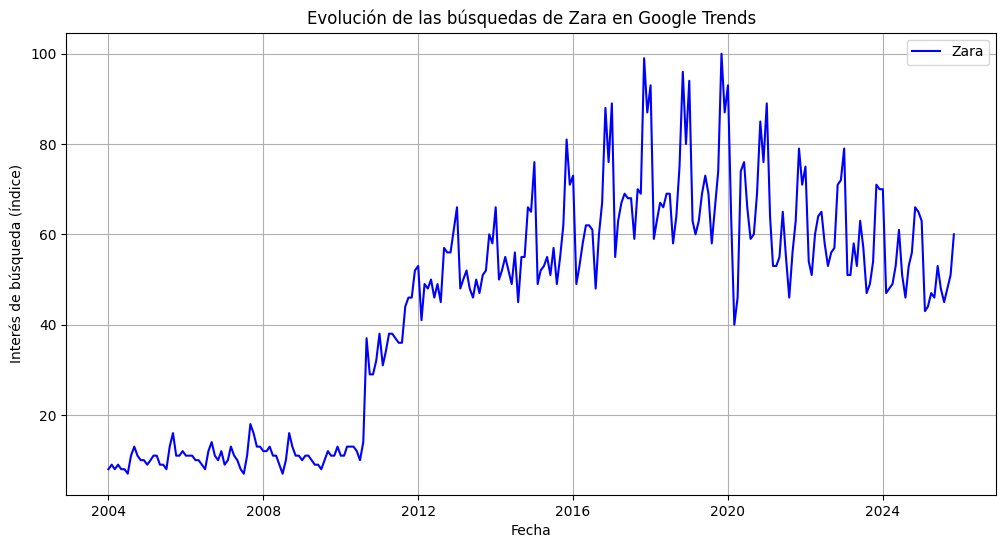

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], df['Zara'], label='Zara', color='blue')

plt.title('Evolución de las búsquedas de Zara en Google Trends')
plt.xlabel('Fecha')
plt.ylabel('Interés de búsqueda (índice)')
plt.legend()
plt.grid(True)
plt.show()

## Resumen de la Evolución de las Búsquedas de 'Zara'

### Observaciones de las Estadísticas Descriptivas:

*   **Media (44.30)**: El interés promedio de búsqueda de 'Zara' a lo largo del periodo es de aproximadamente 44.30. Esto indica un nivel moderado de interés en Google Trends.
*   **Desviación Estándar (25.00)**: La desviación estándar es relativamente alta (25.00), lo que sugiere una variabilidad considerable en el interés de búsqueda. Esto implica que las búsquedas de 'Zara' no han sido constantes, sino que han fluctuado significativamente a lo largo del tiempo.
*   **Mínimo (7.00)**: El valor más bajo de interés de búsqueda registrado para 'Zara' fue 7, lo que indica periodos de muy bajo interés.
*   **Máximo (100.00)**: El valor más alto de interés de búsqueda fue 100, que es el pico de popularidad relativa para el término 'Zara' dentro del periodo analizado, mostrando momentos de gran relevancia.
*   **Cuartiles (25%: 13.00, 50% (Mediana): 51.00, 75%: 63.00)**: El 25% de las veces, el interés de búsqueda fue igual o inferior a 13.00. La mediana de 51.00 indica que la mitad de las observaciones están por debajo de este valor. El 75% de las veces, el interés fue igual o inferior a 63.00. La diferencia entre la mediana y el 75% es menor que entre el 25% y la mediana, lo que podría indicar una distribución ligeramente asimétrica, con más datos concentrados en los valores de interés más altos o un crecimiento en el tiempo.

### Observaciones del Gráfico de Línea:

*   **Tendencia General**: El gráfico muestra una tendencia general al alza en el interés de búsqueda de 'Zara' desde 2004 hasta aproximadamente 2018-2020. Inicialmente, el interés era bajo, pero creció de manera constante durante muchos años.
*   **Picos de Popularidad**: Se observan picos recurrentes, especialmente alrededor de ciertos meses (posiblemente relacionados con lanzamientos de colecciones, rebajas o temporadas de compras como Black Friday o Navidad). El valor máximo de 100 se alcanza en varios puntos, lo que sugiere momentos de muy alta popularidad.
*   **Estacionalidad**: Parece haber un patrón estacional, con un aumento en las búsquedas en ciertos periodos del año y una disminución en otros. Esto es común en la moda y el comercio minorista.
*   **Descenso Reciente**: Hacia los años más recientes (aproximadamente desde 2020 en adelante), el gráfico sugiere una posible estabilización o incluso un ligero descenso en el interés de búsqueda comparado con los picos más altos de años anteriores. Aunque sigue siendo significativo, no alcanza la misma frecuencia o intensidad de los picos de la década de 2010.
*   **Fluctuaciones**: Coherente con la alta desviación estándar, el gráfico evidencia fluctuaciones notables mes a mes, aunque la tendencia a largo plazo muestra crecimiento y luego estabilidad/ligero declive.

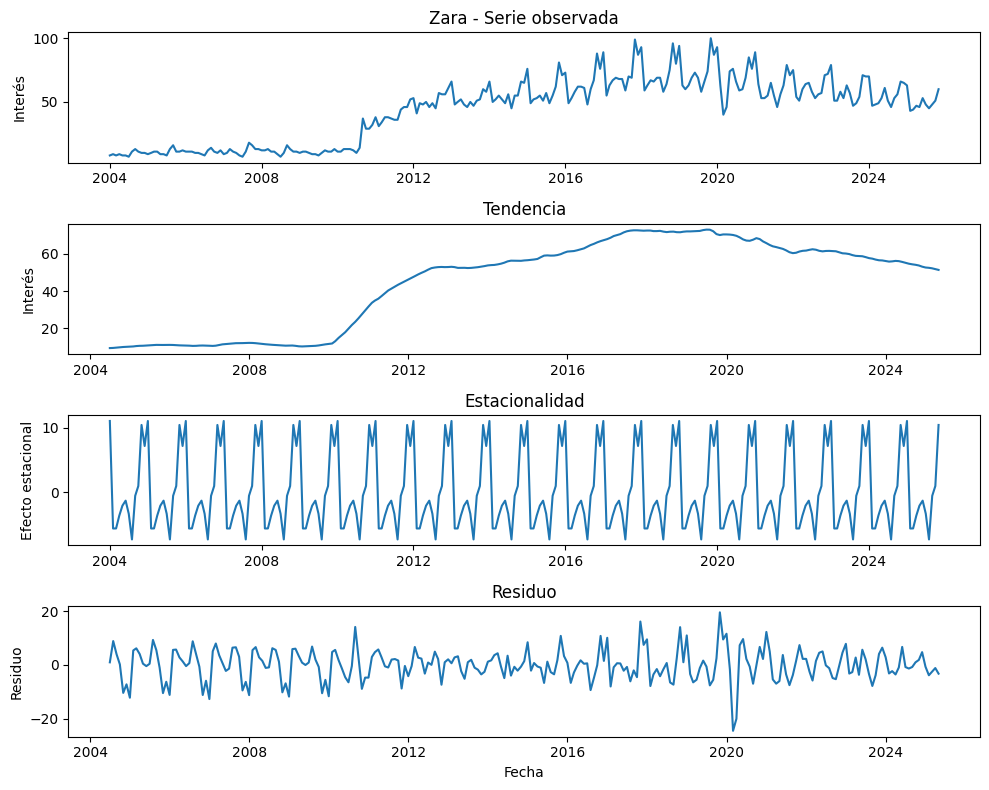

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Cargar el dataset limpio
ruta_csv = 'tendencias_limpias_05.csv'  # ajusta la ruta si es necesario
df = pd.read_csv(ruta_csv)

# 2. Convertir la columna Fecha a tipo datetime y usarla como índice
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.set_index('Fecha')

# 3. Extraer la serie de Zara
zara = df['Zara']

# 4. Descomposición temporal (modelo aditivo, frecuencia mensual = 12)
# Si statsmodels te da un warning por el periodo, asegúrate de tenerlo como period=12
result = seasonal_decompose(zara, model='additive', period=12)

# 5. Representar los cuatro componentes
plt.figure(figsize=(10, 8))

# Serie observada
plt.subplot(4, 1, 1)
plt.plot(result.observed)
plt.title('Zara - Serie observada')
plt.ylabel('Interés')

# Tendencia
plt.subplot(4, 1, 2)
plt.plot(result.trend)
plt.title('Tendencia')
plt.ylabel('Interés')

# Estacionalidad
plt.subplot(4, 1, 3)
plt.plot(result.seasonal)
plt.title('Estacionalidad')
plt.ylabel('Efecto estacional')

# Residuo
plt.subplot(4, 1, 4)
plt.plot(result.resid)
plt.title('Residuo')
plt.ylabel('Residuo')
plt.xlabel('Fecha')

plt.tight_layout()
plt.show()


## Final Task

### Subtask:
Proporcionar un resumen del análisis descriptivo de la serie temporal de 'Zara', destacando las observaciones clave de las estadísticas y el gráfico.


## Summary:

### Q&A
The descriptive analysis of the 'Zara' time series data reveals the following key observations from the statistics and the plot:

**Observations from Descriptive Statistics:**
*   **Mean (44.30)**: The average search interest for 'Zara' was approximately 44.30, indicating a moderate level of interest.
*   **Standard Deviation (25.00)**: A relatively high standard deviation of 25.00 suggests significant variability and fluctuations in search interest over time.
*   **Range (Min 7.00, Max 100.00)**: The interest ranged from a low of 7.00 to a high of 100.00, showing periods of both very low and peak popularity.
*   **Quartiles**: The 25th percentile is 13.00, the median (50th percentile) is 51.00, and the 75th percentile is 63.00. This distribution suggests a possible slight asymmetry, with more data concentrated in higher interest values or growth over time, as the range from the median to the 75th percentile is smaller than from the 25th percentile to the median.

**Observations from the Line Plot:**
*   **Overall Trend**: The plot shows a general upward trend in 'Zara' search interest from 2004 until approximately 2018-2020, starting low and growing consistently.
*   **Peaks of Popularity**: Recurrent peaks are visible, with the interest reaching the maximum value of 100 at several points, likely coinciding with collection launches, sales, or holiday shopping seasons.
*   **Seasonality**: There appears to be a seasonal pattern, with increases in searches during specific periods of the year and decreases in others, common in fashion retail.
*   **Recent Decline/Stabilization**: From around 2020 onwards, the graph suggests a potential stabilization or even a slight decline in search interest compared to the previous decade's highest peaks.
*   **Fluctuations**: The plot visually confirms the notable month-to-month fluctuations, which align with the high standard deviation.

### Data Analysis Key Findings
*   The average search interest for 'Zara' across the period was 44.30, with a substantial standard deviation of 25.00, indicating significant volatility.
*   Search interest for 'Zara' exhibited a wide range, from a minimum of 7.00 to a maximum of 100.00, suggesting periods of both low engagement and peak popularity.
*   The time series displayed an initial upward trend from 2004 to approximately 2018-2020, followed by a potential stabilization or slight decline in recent years.
*   Recurring seasonal peaks were evident in the search interest, likely influenced by retail cycles and events.

### Insights or Next Steps
*   Further investigation into the specific dates of the peaks (values of 100) could reveal correlations with marketing campaigns, product launches, or major sales events to understand drivers of peak interest.
*   Analyzing the seasonal patterns more deeply (e.g., using decomposition techniques) could help in forecasting future search interest and optimizing marketing strategies around predictable surges or dips.
